<a href="https://colab.research.google.com/github/Sabarinathan-mb/Data_Engi-Workshop/blob/main/Day_2/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported seccessfully!")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported seccessfully!
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [28]:
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]}students,{df.shape[1]}columns")
print(f"columns: {df.columns.tolist}")
print(f"\nfirst 3 row:")
df.head(3)

Dataset loaded:30students,13columns
columns: <bound method IndexOpsMixin.tolist of Index(['student_id', 'name', 'age', 'gender', 'department', 'semester',
       'math_score', 'science_score', 'english_score', 'programming_score',
       'attendance_percentage', 'city', 'admission_year'],
      dtype='object')>

first 3 row:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [29]:
conn=sqlite3.connect('college.db')
cursor=conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
print(f"Total students in the database:{count}")

Total students in the database:30


In [30]:
def run_query(sql, description="student"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql, conn)
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_quey(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_quey(sql_string, description_label)


In [31]:
query1="""SELECT * FROM students  Limit 10"""

result1=run_query(query1, "First 10 students")
result1

First 10 students


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [32]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [33]:
query3="""Select name,math_score,science_score,programming_score,attendance_percentage FROM students where department="Computer Science" order by programming_score DESC"""
result3=run_query(query3,"Computer Science Students")
result3

Computer Science Students


,name,math_score,science_score,programming_score,attendance_percentage
0,Ananya Das,95,89,97,98
1,Tanvi Mehta,93,90,96,97
2,Arjun Nair,92,88,95,90
3,Akanksha Yadav,91,93,94,95
4,Divya Singh,88,91,93,96
5,Swati Kulkarni,90,87,92,94
6,Aarav Sharma,85,78,91,92
7,Amit Bose,86,82,89,91
8,Suresh Rao,83,86,88,88
9,Gaurav Shukla,84,79,87,87


In [34]:
query4="""Select name , department, attendance_percentage from students where department!="Civil" and attendance_percentage>90 order by programming_score desc"""
result4=run_query(query4,"Students with attendance percentage greater than 90")
result4

Students with attendance percentage greater than 90


,name,department,attendance_percentage
0,Ananya Das,Computer Science,98
1,Tanvi Mehta,Computer Science,97
2,Akanksha Yadav,Computer Science,95
3,Divya Singh,Computer Science,96
4,Swati Kulkarni,Computer Science,94
5,Aarav Sharma,Computer Science,92
6,Amit Bose,Computer Science,91
7,Ritu Agarwal,Electronics,93
8,Kavya Nambiar,Mechanical,91
9,Sneha Reddy,Mechanical,95


In [35]:
query6 = """SELECT department, AVG(math_score) as avg_math_score
FROM students
GROUP BY department
HAVING AVG(math_score) > 70
ORDER BY avg_math_score DESC;"""
result6 = run_query(query6, "Departments with Average Math Score > 70")
result6

Departments with Average Math Score > 70


,department,avg_math_score
0,Computer Science,85.615385
1,Mechanical,71.000000
2,Electronics,71.000000


In [36]:
query5="""select gender,count(*) as num_students,round(avg(math_score),2) as avg_math, round(avg(science_score),2) as avg_science, round(avg(programming_score),2) as avg_programmming, round(avg(attendance_percentage),2)as avg_attendance from students group by gender"""
result5=run_query(query5)
result5

student


,gender,num_students,avg_math,avg_science,avg_programmming,avg_attendance
0,Female,15,78.47,81.20,70.2,88.53
1,Male,15,73.67,74.47,65.0,80.47


Average Attendance by Gender


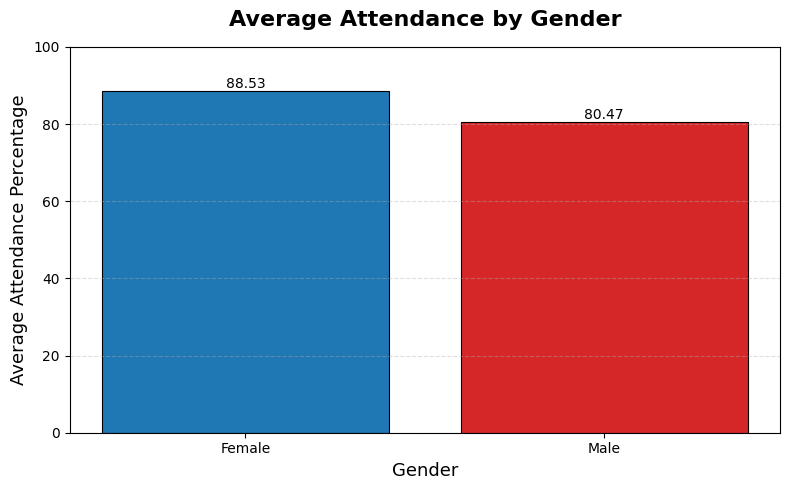

In [63]:
import matplotlib.pyplot as plt

# SQL query to get average attendance by gender
chart2_sql = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC"""

chart2_data = run_query(chart2_sql, "Average Attendance by Gender")

fig, ax = plt.subplots(figsize=(8, 5))

# Define colors for genders
colors = ['tab:blue', 'tab:']

bars = ax.bar(
    chart2_data['gender'],
    chart2_data['avg_attendance'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add labels to the bars
for bar in bars:
  height = bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      height,
      f'{height:.2f}',
      ha='center',
      va='bottom',
      fontsize=10,
      color='black'
  )

ax.set_title('Average Attendance by Gender', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=13)
ax.set_ylabel('Average Attendance Percentage', fontsize=13)
ax.set_ylim(0, 100) # Attendance is a percentage
ax.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

Top 8 Students by Total Marks Percentage


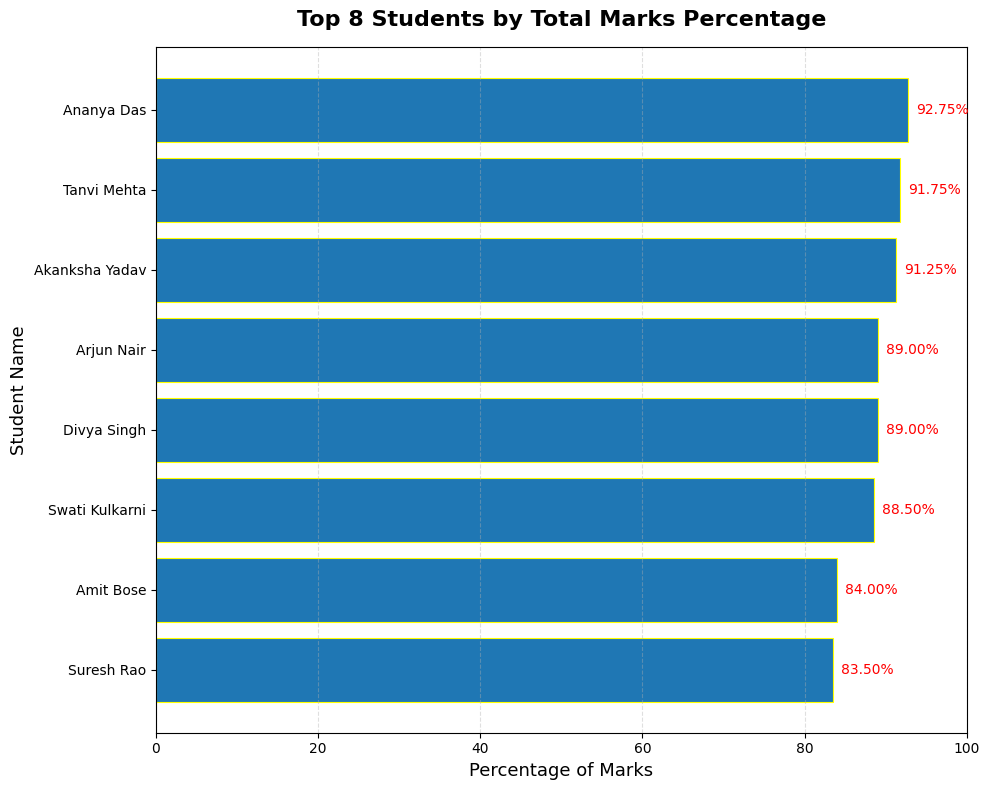

In [71]:
import matplotlib.pyplot as plt

chart3_sql = """
SELECT
    name,
    (math_score + science_score + english_score + programming_score) AS total_marks,
    ROUND(((math_score + science_score + english_score + programming_score) * 100.0 / 400.0), 2) AS percentage_marks
FROM students
ORDER BY total_marks DESC
LIMIT 8
"""

chart3_data = run_query(chart3_sql, "Top 8 Students by Total Marks Percentage")

fig, ax = plt.subplots(figsize=(10, 8))


bars = ax.barh(
    chart3_data['name'],
    chart3_data['percentage_marks'],
    color='tab:blue',
    edgecolor='yellow',
    linewidth=0.8
)


for bar in bars:
  width = bar.get_width()
  ax.text(
      width + 1,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.2f}%',
      va='center',
      ha='left',
      fontsize=10,
      color='red'
  )

ax.set_title('Top 8 Students by Total Marks Percentage', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Percentage of Marks', fontsize=13)
ax.set_ylabel('Student Name', fontsize=13)
ax.set_xlim(0, 100) # Percentage from 0 to 100
ax.grid(axis='x', alpha=0.4, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Student Distribution by Department


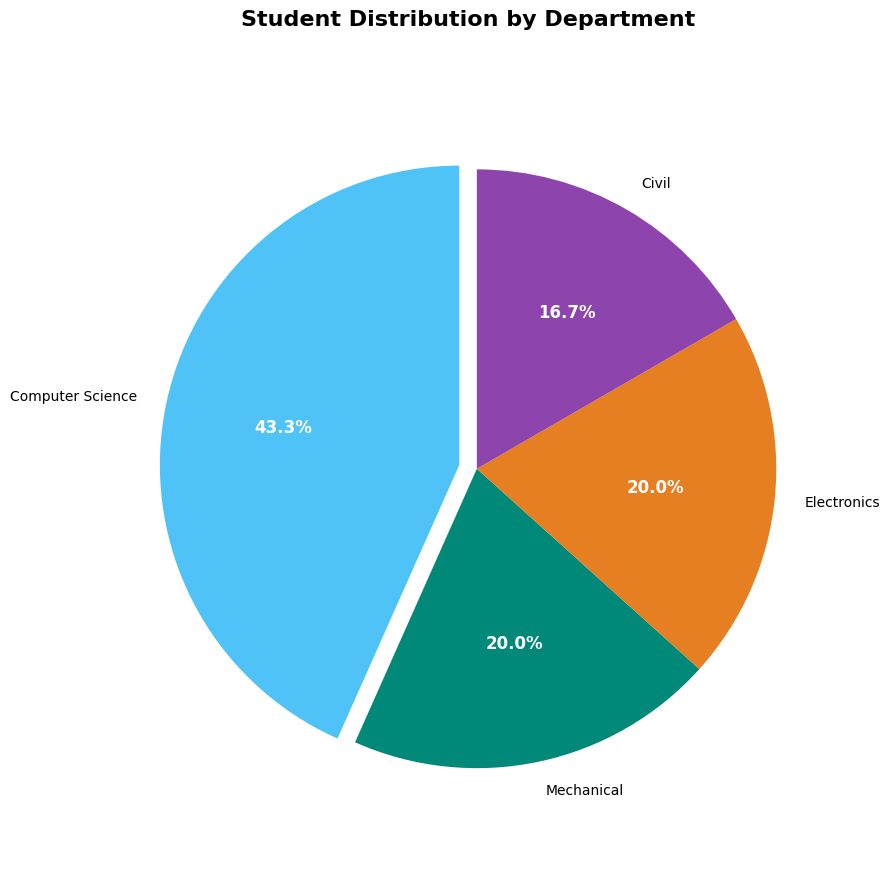

In [74]:
import matplotlib.pyplot as plt

chart4_sql="""select department,count(*) as num_students from students group by department order by num_students desc"""

chart4_data = run_query(chart4_sql, "Student Distribution by Department")

labels=chart4_data['department'].tolist()
sizes=chart4_data['num_students'].tolist()
colors=['#4FC3F7', '#008978','#E67E22','#8E44AD']
explode=[0.06,0,0,0]

fig ,ax = plt.subplots(figsize=(9,9))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title('Student Distribution by Department', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()
plt.show()

In [75]:
chart6_sql="""select department,round(avg(attendance_percentage),2) as avg_atten from students group by department having avg_atten>85
 """
chart6=pd.read_sql_query(chart6_sql,conn)
chart6

,department,avg_atten
0,Computer Science,90.69


In [76]:
chart5_sql="""select gender,round(avg(programming_score),2) as avg_prog from students group by gender having gender='Female'"""
chart5=pd.read_sql_query(chart5_sql,conn)
chart5

,gender,avg_prog
0,Female,70.2


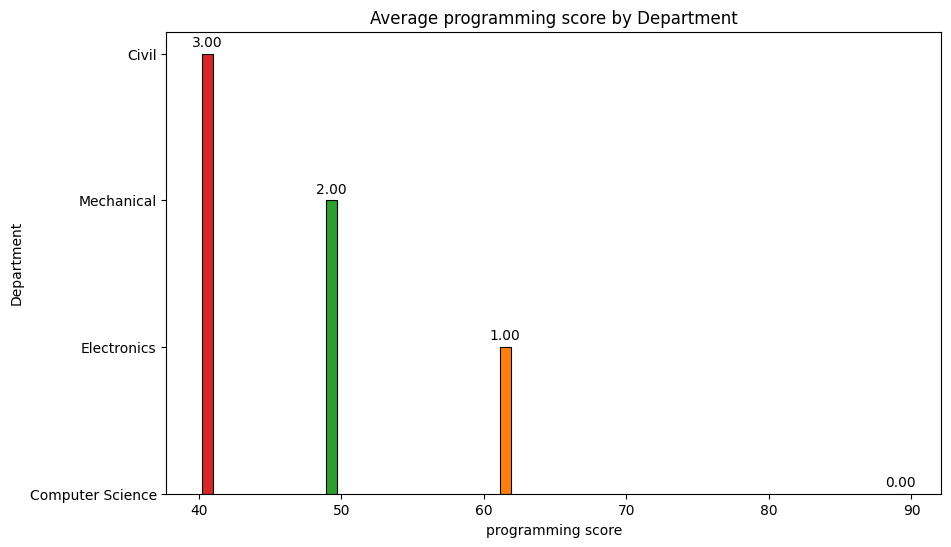

In [78]:
chart1_sql = """
SELECT department,
       ROUND(AVG(programming_score),2) AS avg_program
FROM students
GROUP BY department
ORDER BY avg_program DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10,6))

bar_color = ['tab:blue','tab:orange','tab:green','tab:red']

bars = ax.bar(
    chart1_data['avg_program'],
    chart1_data['department'],

    color=bar_color,
    edgecolor='black',
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f'{height:.2f}',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0,3),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_ylabel('Department')
ax.set_xlabel('programming score')
ax.set_title('Average programming score by Department')

plt.show()
